In [76]:
import numpy as np
import h5py
import time
import datetime

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.make_orbits import *
from helpers.config import *
from pytdi.michelson import *
from pytdi import LISATDICombination
from scipy.signal import welch

from lisaorbits import KeplerianOrbits, EqualArmlengthOrbits, OEMOrbits
from lisaglitch import LPFLibraryGlitch, IntegratedShapeletGlitch
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

In [6]:
Mc_array = 10**np.random.uniform(6, 7, size=667)
q_array = np.random.uniform(1, 5, size=667)

m1_array = Mc_array * ((1 + q_array)**(1/5) / q_array**(3/5))
m2_array = m1_array * q_array

In [7]:
chirp_mass = (m1_array * m2_array)**(3/5) / (m1_array + m2_array)**(1/5)
np.log10(np.min(chirp_mass)), np.log10(np.max(chirp_mass))

(np.float64(6.001736213472592), np.float64(6.996978817032616))

In [3]:
def estimate_psd(data, sample_freq, nperseg, noverlap=None):
    
    f_psd, psd = welch(
        data,
        fs=sample_freq,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
        return_onesided=True
    )
    return f_psd, psd

In [4]:
disable_dopplers = False
disable_noise = False
#disable_noise = ['test-mass', 'oms']
#disable_noise = ['laser']
disable_noise = ['laser', 'test-mass', 'oms']
orbits3_path = str(DIST / 'orbits' / 'orbits2.h5')
with h5py.File(orbits3_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25), 't_inj': 5 * 3600}

lisa_instrument = Instrument(size=pipe['size'], dt=pipe['dt'], t0=pipe['t0'],
        orbits=orbits3_path, physics_upsampling=1, aafilter=None,
        glitches=None, gws=None)

if disable_dopplers:
    lisa_instrument.disable_dopplers()
if disable_noise is True:
    lisa_instrument.disable_all_noises()
elif disable_noise is not False:
    lisa_instrument.disable_all_noises(disable_noise)

if os.path.exists(simulation_path):
    os.remove(simulation_path)

lisa_instrument.write(simulation_path)
data = Data.from_instrument(simulation_path)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [25]:
#data.delay_derivatives = None
X_data = X1.build(**data.args)(data.measurements)
Y_data = Y1.build(**data.args)(data.measurements)
Z_data = Z1.build(**data.args)(data.measurements)

In [6]:
mytdi_Y = LISATDICombination({
    'sci_12': [
        (1, []),
        (1, ['D_12', 'D_21']),
        (-1, ['D_32', 'D_23'])
    ],
    'sci_21': [
        (1, ['D_12']),
        (-1, ['D_32', 'D_23', 'D_12'])
    ],
    'sci_32': [
        (1, ['D_12', 'D_21']),
        (-1, [])
    ],
    'sci_23': [
        (1, ['D_12', 'D_21', 'D_32']),
        (-1, ['D_32'])
    ],
})

Y_data = mytdi_Y.build(**data.args)(data.measurements)

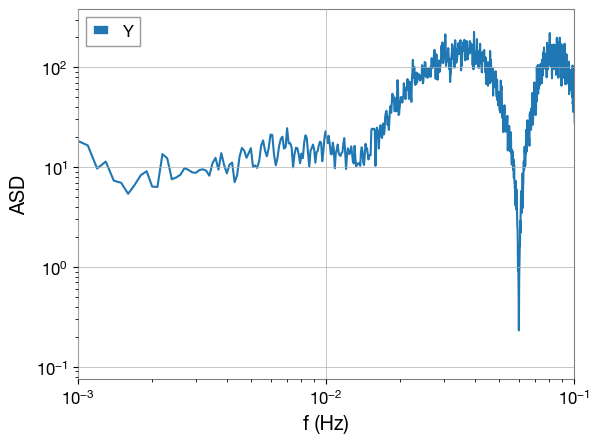

In [47]:
#channel = data.measurements['sci_12']
f_psd1, psd1 = estimate_psd(X_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd2, psd2 = estimate_psd(Y_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd3, psd3 = estimate_psd(Z_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)

#plt.loglog(f_psd1, np.sqrt(psd1), label='X')
plt.loglog(f_psd2, np.sqrt(psd2), label='Y')
#plt.loglog(f_psd3, np.sqrt(psd3), label='Z')
plt.xlim(1e-3, 1e-1)
#plt.ylim(1e-7, 1e-3)
plt.xlabel('f (Hz)')
plt.ylabel('ASD')
plt.legend()
plt.show()

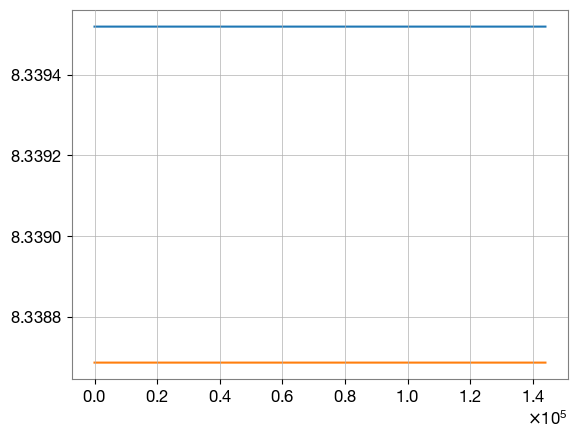

In [19]:
plt.plot(data.args['delays']['d_12'])
plt.plot(data.args['delays']['d_21'])

In [96]:
mytdi = LISATDICombination({
    'sci_12': [(1, ['D_12'])]
})

shifted = mytdi.build(**data.args)(data.measurements)

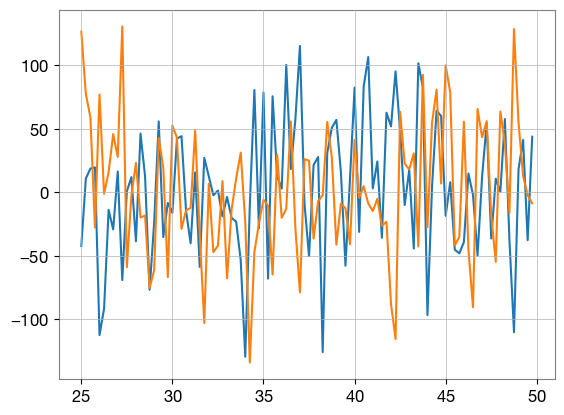

In [99]:
t = np.arange(0, 10*3600, 0.25)
plt.plot(t[100:200], data.measurements['sci_12'][100:200])
plt.plot(t[100:200], shifted[100:200])

In [ ]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

In [15]:
with h5py.File(orbits_path, "r") as f:
    for key, value in f.attrs.items():
        print(key, value)

check_input True
dt 0.25
ext raise
filename_1 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem1
filename_2 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem2
filename_3 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem3
generator OEMOrbits
git_url https://gitlab.in2p3.fr/lisa-simulation/orbits
ignore_shapiro False
interp_order 5
size 345600
t0 2073297530.8174996
t_end 2412464618.8153605
t_init 2073211130.8174996
t_start 2073211130.8174996
tt_method analytic
tt_niter 4
tt_order 2
version 2.4.2


In [159]:
path = DIST / 'orbits' / 'orbits3.h5'
lisa_orbits = EqualArmlengthOrbits()
lisa_orbits.write(path)

In [6]:
with h5py.File(orbits_path, "r") as f:
    for key, value in f.attrs.items():
        print(key, value)

check_input True
dt 100000.0
ext raise
filename_1 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem1
filename_2 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem2
filename_3 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem3
generator OEMOrbits
git_url https://gitlab.in2p3.fr/lisa-simulation/orbits
ignore_shapiro False
interp_order 5
size 630
t0 2136283130.8174996
t_end 2412464618.8153605
t_init 2073211130.8174996
t_start 2073211130.8174996
tt_method analytic
tt_niter 4
tt_order 2
version 2.4.2


In [24]:
orb = h5py.File(orbits_path, "r")
orb_size = orb.attrs['size']
orb_dt = orb.attrs['dt']

In [25]:
x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

In [26]:
L12 = np.linalg.norm(r1 - r2, axis=1)
L23 = np.linalg.norm(r2 - r3, axis=1)
L31 = np.linalg.norm(r3 - r1, axis=1)

print(f'L12: {L12[0]:.4e}')
print(f'L23: {L23[0]:.4e}')
print(f'L31: {L31[0]:.4e}')

L12: 2.5113e+09
L23: 2.4971e+09
L31: 2.5012e+09


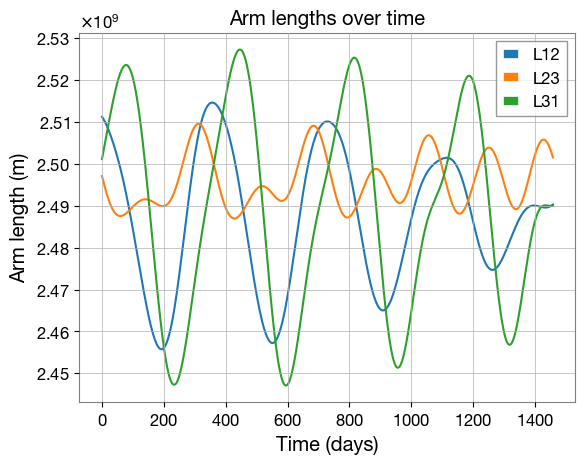

In [27]:
t = np.arange(0, orb_size*orb_dt, orb_dt)
plt.plot(t/86400, L12)
plt.plot(t/86400, L23)
plt.plot(t/86400, L31)
plt.xlabel('Time (days)')
plt.ylabel('Arm length (m)')
plt.title('Arm lengths over time')
plt.legend(['L12', 'L23', 'L31'])
plt.show()

In [6]:
glitch = ShapeletGlitch(
    level=1e-12,
    beta=500,
    t_inj=5*3600,
    inj_point='tm_12'
)

In [3]:
print(plt.rcParams["text.usetex"])
print(plt.rcParams["font.family"])
print(plt.rcParams["font.weight"])

False
['sans-serif']
normal


In [4]:
plt.rcParams["text.usetex"] = False
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family'] = 'DejaVu Sans'

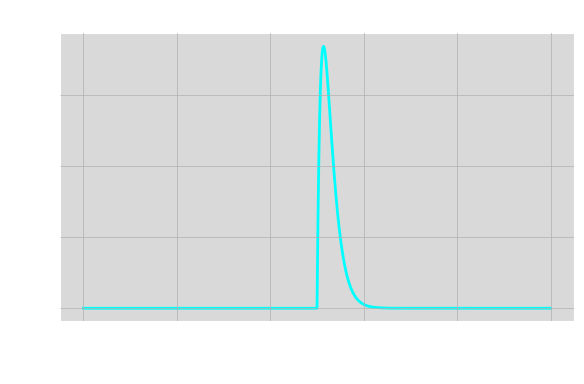

In [7]:
t = np.arange(0, 10*3600, 0.25)
y = glitch.compute_signal(t)

fig, ax = plt.subplots(figsize=(6, 4))

# Transparent figure and axes backgrounds
fig.patch.set_alpha(0)
ax.set_facecolor((0, 0, 0, 0.15))

ax.plot(t/3600, y, color='cyan', lw=2)

# White labels
ax.set_xlabel('Time (hours)', color='white', fontweight='bold', fontsize=12)
ax.set_ylabel(r'Acceleration shift from free fall (m/s$^2$)',
               color='white',fontweight='bold', fontsize=10)
ax.set_title('Shapelet Glitch Model', color='white', fontweight='bold')

# White ticks
ax.tick_params(colors='white')

# White axis lines
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()

# Save with transparent background
plt.savefig(
    FIGURES / 'random'/ 'shapelet_glitch_casca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [91]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 5e6, 'm2': 5e5, 'd': 1e4,
        'spin1': 0, 'spin2': 0, 't_inj': 5*3600, 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': 5*3600, 'beta':17,
             'level':2*2.28e-12*17, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, PIPE,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=PIPE['keep_noises']
        )
raw_dict = run_tdi(simulation_path, PIPE)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [94]:
event = {'t_inj':PIPE['t_inj']}
res = 512
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
QT_mixed = np.zeros((512, 512, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, PIPE, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data
end = time.time()
print(end - start)

0.5846519470214844


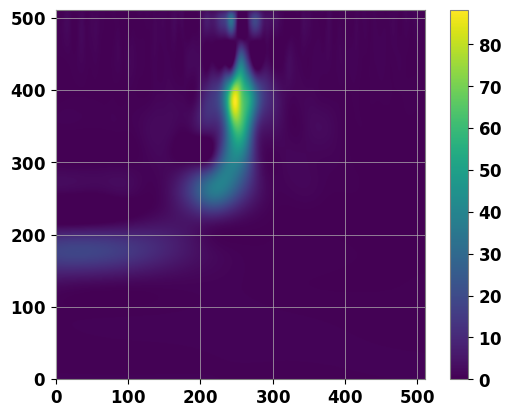

In [95]:
plt.imshow(QT_mixed[:, :, 0], origin='lower')
#plt.clim(0, 60)
plt.colorbar()
plt.show()

In [98]:
run_simulation(
            gws, glitches, PIPE,
            None, glitch_path, orbits_path,
            simulation_path,
            disable_noise=PIPE['keep_noises']
        )
raw_dict = run_tdi(simulation_path, PIPE)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [99]:
event = {'t_inj':PIPE['t_inj']}
res = 512
spec = SPECS['high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
QT_mixed2 = np.zeros((512, 512, 3))
for channel in ['A', 'E', 'T']:
    t_mixed2, f_mixed2, data2 = generate_qscan(tdi_dict, channel, PIPE, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)
    QT_mixed2[:, :, ['A', 'E', 'T'].index(channel)] = data2
end = time.time()
print(end - start)

0.5548391342163086


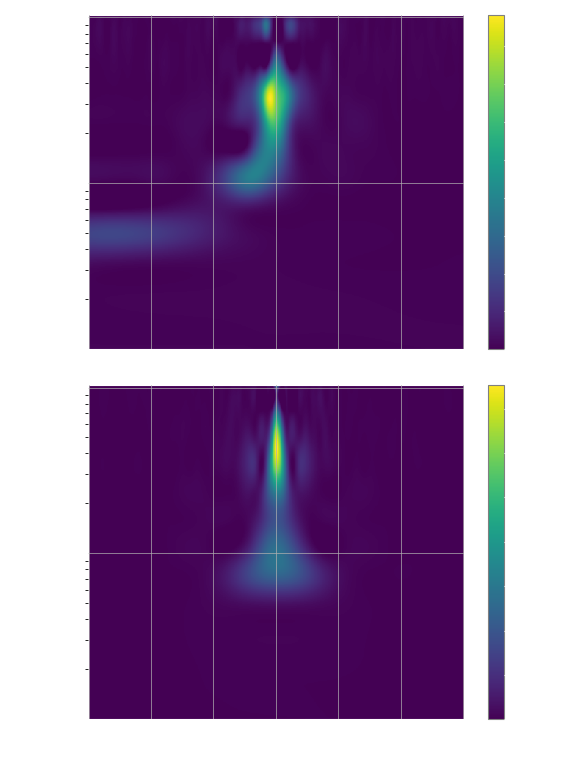

In [100]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(6, 8),
    sharex=True
)
cmap = 'viridis'
# Transparent backgrounds
fig.patch.set_alpha(0)

for a in ax:
    a.set_facecolor('none')

# First spectrogram
pcm1 = ax[0].pcolormesh(
    (t_mixed - t_mixed[0])/3600,
    f_mixed,
    QT_mixed[:, :, 0],
    shading='auto',
    cmap=cmap
)

ax[0].set_ylabel('Frequency (Hz)', color='white')
ax[0].set_yscale('log')

# Second spectrogram
pcm2 = ax[1].pcolormesh(
    (t_mixed2 - t_mixed2[0])/3600,
    f_mixed2,
    QT_mixed2[:, :, 0],
    shading='auto',
    cmap=cmap
)

ax[1].set_xlabel('Time (hrs)', color='white')
ax[1].set_ylabel('Frequency (Hz)', color='white')
ax[1].set_yscale('log')

# White ticks and spines
for a in ax:
    a.tick_params(colors='white')

    for spine in a.spines.values():
        spine.set_color('white')

# Colorbars
cbar1 = fig.colorbar(pcm1, ax=ax[0])
cbar1.set_label('Normalized energy', color='white')
cbar1.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar1.ax.get_yticklabels(), color='white')

cbar2 = fig.colorbar(pcm2, ax=ax[1])
cbar2.set_label('Normalized energy', color='white')
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.get_yticklabels(), color='white')

plt.tight_layout()

plt.savefig(
    FIGURES/'random'/'qscan_examples.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()

In [55]:
lm_results_path = TRAINING_RESULTS/ 'low_mass'/ 'good_runs' /'run_040526_211125'
lm_cm = np.load(lm_results_path / 'confusion_matrix.npz')['cm']

hm_results_path = TRAINING_RESULTS/ 'high_mass'/ 'good_runs' /'run_150426_170834'
hm_cm = np.load(hm_results_path / 'confusion_matrix.npz')['cm']

ehm_results_path = TRAINING_RESULTS/ 'ext_high_mass'/ 'good_runs' /'run_100426_141342'
ehm_cm = np.load(ehm_results_path / 'confusion_matrix.npz')['cm']

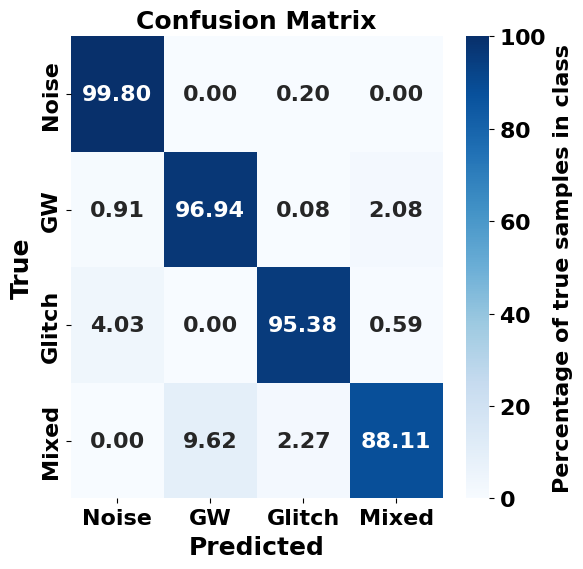

In [117]:
import seaborn as sns

cm = (lm_cm + hm_cm + ehm_cm)/3
labels_names = ["Noise", "GW", "Glitch", "Mixed"]

fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# Transparent backgrounds
fig.patch.set_alpha(0)
axes.set_facecolor('none')

hm = sns.heatmap(
    cm,
    annot=True,
    annot_kws={"size": 16},
    cmap='Blues',
    ax=axes,
    fmt=".2f",
    xticklabels=labels_names,
    yticklabels=labels_names,
    vmin=0,
    vmax=100,
    cbar=True
)

# White axis labels
axes.set_xlabel("Predicted", color='black', fontsize=18)
axes.set_ylabel("True", color='black', fontsize=18)
axes.set_title("Confusion Matrix", color='black', fontsize=18)

# White tick labels
#axes.tick_params(colors='black')
axes.tick_params(axis='both', labelsize=16, colors='black')
# Make annotation text white
#for text in axes.texts:
 #   text.set_color('white')

# Colorbar
cbar = hm.collections[0].colorbar
cbar.set_label(
    "Percentage of true samples in class",
    color='black',
    fontsize=16
)
cbar.ax.yaxis.set_tick_params(color='black', labelsize=16)
plt.setp(cbar.ax.get_yticklabels(), color='black')

# White spines
for spine in axes.spines.values():
    spine.set_color('white')

axes.grid(False)

plt.savefig(
    FIGURES/'random'/"confusion_matrix.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()

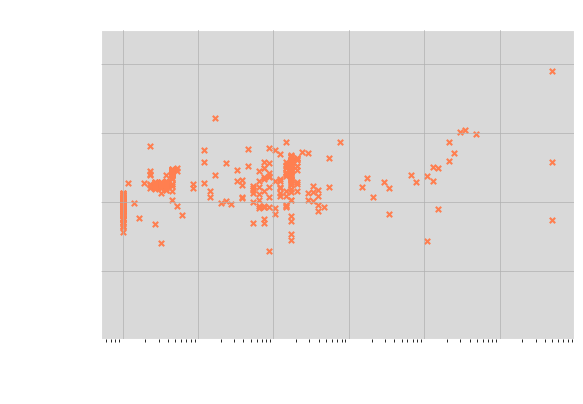

In [89]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas, lpf_levels = params[:, 0], np.abs(params[:, 1])

fig, ax = plt.subplots(figsize=(6, 4))

# Transparent figure background
fig.patch.set_alpha(0)

# Semi-transparent black plotting area
ax.set_facecolor('black')
ax.patch.set_alpha(0.15)

# Scatter plot
ax.scatter(lpf_betas, lpf_levels, marker='x', s=15, color='coral')

# Labels
ax.set_xlabel('Timescale (s)', color='white', fontweight='bold', fontsize=12)
ax.set_ylabel(r'Amplitude (m/s$^2$)', color='white', fontweight='bold', fontsize=12)

# Log scales
ax.set_xscale('log')
ax.set_yscale('log')

# White ticks
ax.tick_params(colors='white')

# White spines
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.ylim(1e-17, 1e-8)
plt.title('Model parameters of glitches observed in Pathfinder',
           color='white', fontsize=11)
plt.savefig(
    FIGURES/'random'/'lpf_glitch_params.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [21]:
from pycbc.waveform import get_fd_waveform, get_td_waveform
from lisagwresponse import ResponseFromStrain

class BinaryInspiralGW(ResponseFromStrain):
    """Represents a GW resulting from a binary merger.
    """
    def __init__(self, m1, m2, d, t_inj, spin1=0.0, spin2=0.0, inclination=0.0,\
                 coa=0.0, domain='freq', **kwargs,) -> None:
        super().__init__(**kwargs)
        self.t_inj = float(t_inj)
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.d = float(d)
        self.spin1 = float(spin1)
        self.spin2 = float(spin2)
        self.domain = domain
        self.f_lower = self.compute_flower()
        self.inclination = inclination
        self.coa = coa

        if self.domain == 'time':
            hp_td, hc_td = get_td_waveform(approximant="IMRPhenomXHM", inclination=self.inclination,
                mass1=self.m1, mass2=self.m2, delta_t=1e-3/self.f_lower, f_lower=self.f_lower, coa=self.coa,
                                           distance=self.d, spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_td
            self.hc = hc_td
            
        elif self.domain == 'freq':
            hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM", inclination=self.inclination,
                                       mass1=self.m1, mass2=self.m2, delta_f=self.f_lower/1e3,
                                       f_lower=self.f_lower, distance=self.d, coa=self.coa,
                                           spin1z = self.spin1, spin2z = self.spin2)
            self.hp = hp_fd.to_timeseries()
            self.hc = hc_fd.to_timeseries()
        self.amp_hp = max(self.hp)
        self.amp_hc = max(self.hc)
        self.duration = self.compute_duration()

    def compute_flower(self) -> float:
        c = 3e8
        G = 6.67e-11
        M = (self.m1 + self.m2)*2e30
        r = 6
        return (c**3)/(((6*r)**1.5)*np.pi*G*M)

    def compute_duration(self) -> float:
        """compute an approximate duration for the gw"""
        h = np.sqrt(self.hp**2 + self.hc**2)
        threshold = max(h)/30
        
        mask = h >= threshold
        duration = np.sum(mask) * 0.25
        
        return duration

    def compute_hplus(self, t) -> np.ndarray:
        return self.compute_signal(self.hp, self.amp_hp, t)

    def compute_hcross(self, t) -> np.ndarray:
        return self.compute_signal(self.hc, self.amp_hc, t)

    def compute_signal(self, h, amp, t):
        h.start_time = 0
        peak_time = h.sample_times[np.where(np.array(h) == amp)][0]
        delta_t = self.t_inj - t[0] - 405
        h = h.cyclic_time_shift(-(peak_time - delta_t))
        h.start_time = 0
        
        mask1 = h.sample_times < delta_t + 20000
        sigslice = h[mask1]
        tslice = h.sample_times[mask1]
        tslice = tslice + t[0]
        f = interp1d(tslice, sigslice, kind='cubic',
                         bounds_error=False, fill_value=0)
        return f(t)

In [69]:
# Open the orbit file and extract metadata describing the orbit sampling
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']      # Initial time of orbit file
    orb_size = orb.attrs['size']  # Number of orbit samples
    orb_dt = orb.attrs['dt']      # Time spacing between orbit samples

# Total duration covered by the orbit file
orb_duration = orb_size * orb_dt

pipe = {
    # Start simulation slightly after the orbit file begins
    't0': orb_t0 + 0.01 * orb_duration,

    # Simulation cadence (seconds)
    'dt': 0.25,

    # Total number of simulation samples (10 hours)
    'size': int(10 * 3600 / 0.25),

    # Noise sources retained in the simulation
    # (laser noise excluded assuming ideal TDI cancellation)
    'keep_noises': ['test-mass', 'oms']
}

gw = BinaryInspiralGW(m1=1e5, m2=1e5, d=1e4, t_inj=5*3600 + pipe['t0'], spin1=0.8, spin2=0.8,
                    inclination=np.pi, coa=0, domain='freq',
                    gw_beta=0.0, gw_lambda=0.0, orbits=orbits_path)

# Remove old GW file if it already exists
if os.path.exists(gw_path):
    os.remove(gw_path)

gw.write(
    path=gw_path,
    mode="a",
    dt=pipe['dt'],      # Simulation cadence
    size=pipe['size'],  # Number of samples
    t0=pipe['t0']       # Simulation start time
)


You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported


In [65]:
lisa_instrument = Instrument(
    size=pipe['size'],        # Number of simulation samples
    dt=pipe['dt'],            # Simulation cadence
    t0=pipe['t0'],            # Simulation start time

    # Orbit configuration describing spacecraft motion
    orbits=orbits_path,

    # Injected transient files
    glitches=None,
    gws=gw_path,

    # Random seed for reproducibility
    seed=42
)

# Disable all noise sources except those explicitly retained
lisa_instrument.disable_all_noises(pipe['keep_noises'])

# Remove previous simulation output if it exists
if os.path.exists(simulation_path):
    os.remove(simulation_path)

# Generate and save simulated interferometer measurements
lisa_instrument.write(simulation_path)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz


In [66]:
channels = [X2, Y2, Z2]
tdi_names = ["X", "Y", "Z"]
raw_dict = TimeSeriesDict()

data = Data.from_instrument(simulation_path)
#data.delay_derivative = None

for i in range(len(channels)):
    channel = channels[i]

    # CALCULATE TDI CHANNEL DATA
    tdi_data = channel.build(**data.args)(data.measurements)
    raw_dict[tdi_names[i]] = TimeSeries(tdi_data, t0=pipe['t0'], dt=pipe['dt'])

You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [67]:
from helpers.qtransform import *

event = {'t_inj':5*3600}
res = 256
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-1), trange=(-3, 3), Q=6)
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data

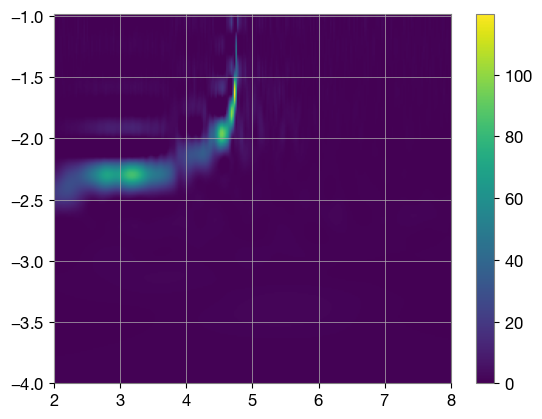

In [68]:
plt.imshow(QT_mixed[:, :, 0], extent=[t_mixed[0]/3600, t_mixed[-1]/3600, np.log10(f_mixed[0]), np.log10(f_mixed[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 5)
plt.show()

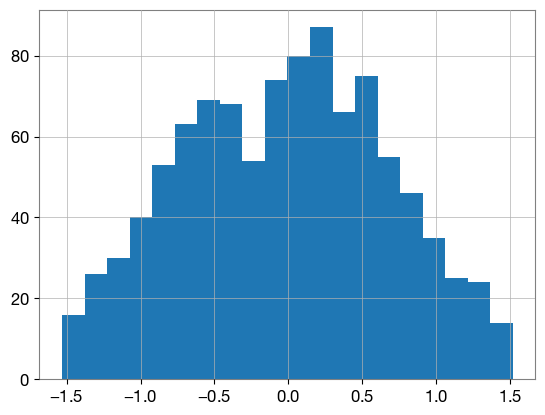

In [63]:
iota = np.arcsin(np.random.uniform(-1, 1, size=1000))
plt.hist(iota, bins=20)
plt.show()

In [71]:
with h5py.File(mixed_ehm_dataset_path, 'r') as h5:
    iota = h5['iota'][:]
    gw_beta = h5['gw_beta'][:]
    spin1 = h5['spin1'][:]
    spin2 = h5['spin2'][:]

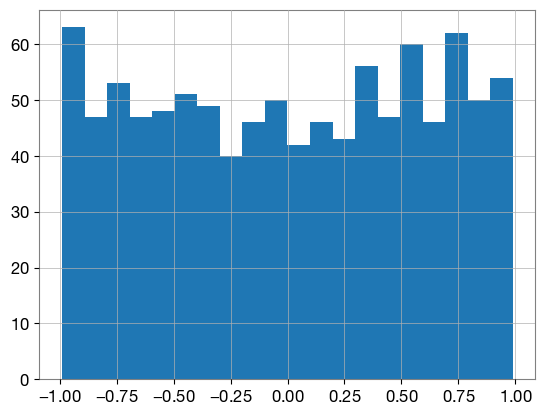

In [75]:
plt.hist(spin2, bins=20)
plt.show()

In [93]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_levels = params[:, 1]

bet_min = 1
amp_min, amp_max = 1e-14, 1e-11

lpf_levels = lpf_levels[lpf_betas > bet_min]
lpf_betas = lpf_betas[lpf_betas > bet_min]

lpf_betas = lpf_betas[(lpf_levels > amp_min) & (lpf_levels < amp_max)]
lpf_levels = lpf_levels[(lpf_levels > amp_min) & (lpf_levels < amp_max)]

In [95]:
new_amps = 10**np.random.uniform(-14, np.log10(1e-11), size=1000)
new_betas = 10**np.random.uniform(0, np.log10(5e3), size=1000)

In [107]:
glitch_dict = {}

with h5py.File(mixed_ehm_dataset_path, "r") as h5:
    for key in list(h5.keys()):
        glitch_dict[key] = h5[key][:]

In [ ]:
snrs = np.max(glitch_dict['QT'], axis=(1,2,3,4))

(1000,)

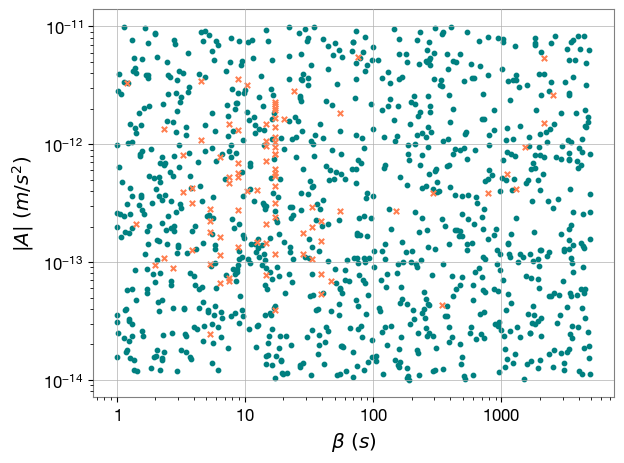

In [108]:
plt.figure(tight_layout=True)
plt.scatter(glitch_dict['beta'], glitch_dict['amp'], color='teal', s=10, label='Sampled parameters')
#plt.scatter(glitch_dict['beta'][snrs > 100], glitch_dict['amp'][snrs > 100],\
 #            color='coral', s=10, label='Quiet Sampled parameters')
#plt.scatter(new_betas, new_amps, color='teal', s=10, label='New sampled parameters')
plt.scatter(lpf_betas, np.abs(lpf_levels), color='coral', s=15, marker='x', label='LPF values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
#plt.legend()
#plt.savefig(DIST/'figures'/'glitch_params.png', dpi=300, bbox_inches='tight')
plt.show()